# Time scales
$$
t_c = \frac{\rho\varepsilon_\mathrm{th}}{\alpha_p a T^4 c}
$$
$$
t_v = \frac{\bar{z}}{v_z(\bar{z})},\quad \bar{z} = \int \rho |z| dz / \int \rho dz
$$
$$
t_\mathrm{es} = \frac{\bar{z}}{c}\tau, \quad \tau = \int \alpha_\mathrm{ross} dz
$$

$z\in[-10\,r_p,\,10\,r_p]$. $t_c=\int\rho\varepsilon_\mathrm{th}dz / \int\alpha_p aT^4c\,dz$ (column thermal
energy over column radiative loss rate).

In [1]:
%load_ext autoreload
%autoreload 2

import os

import matplotlib.pyplot as plt
import numpy as np
import unyt as u

import dev
import richio

a_rad = 4 * u.stefan_boltzmann_constant / u.c

## 10^5

70 0.8809989072418142 day


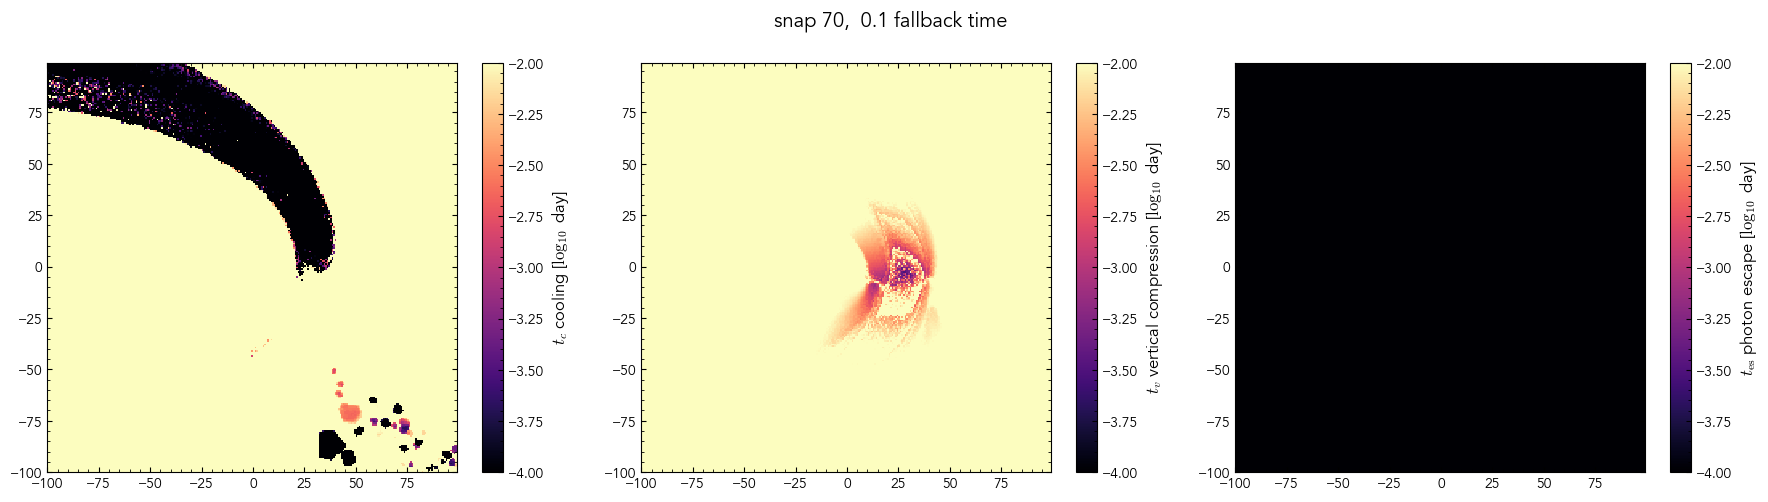

80 1.3344459373001525 day


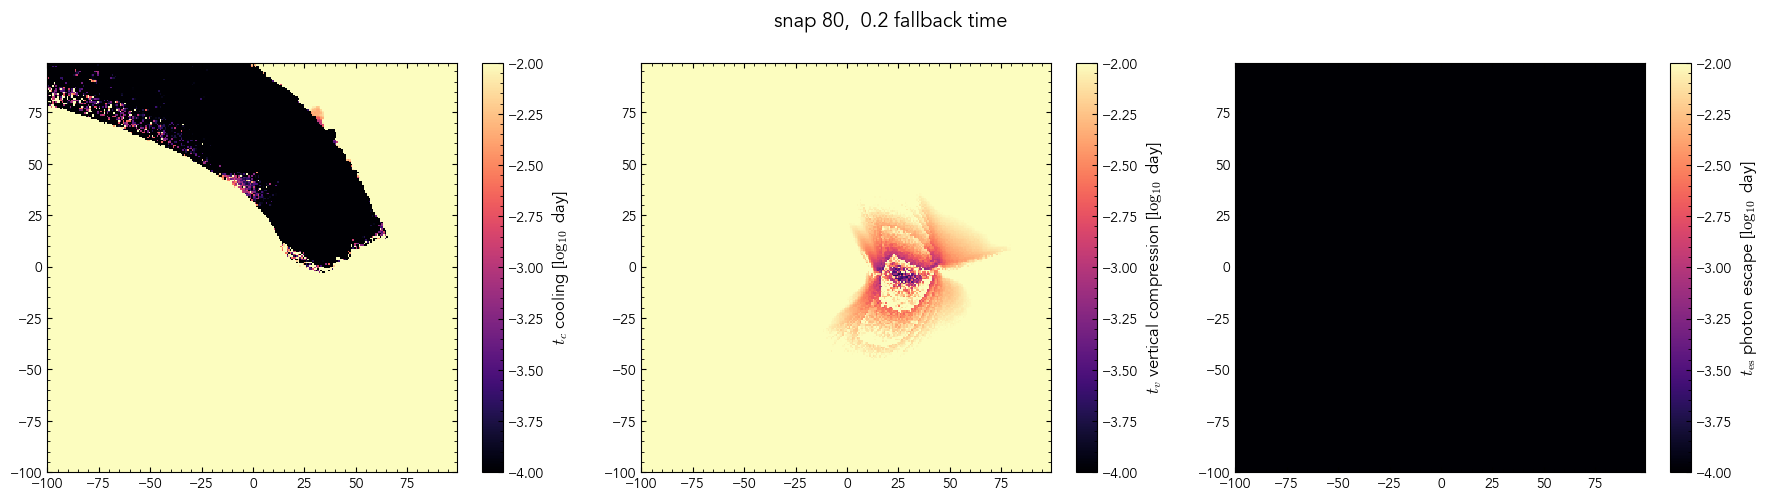

90 1.8657495635079777 day


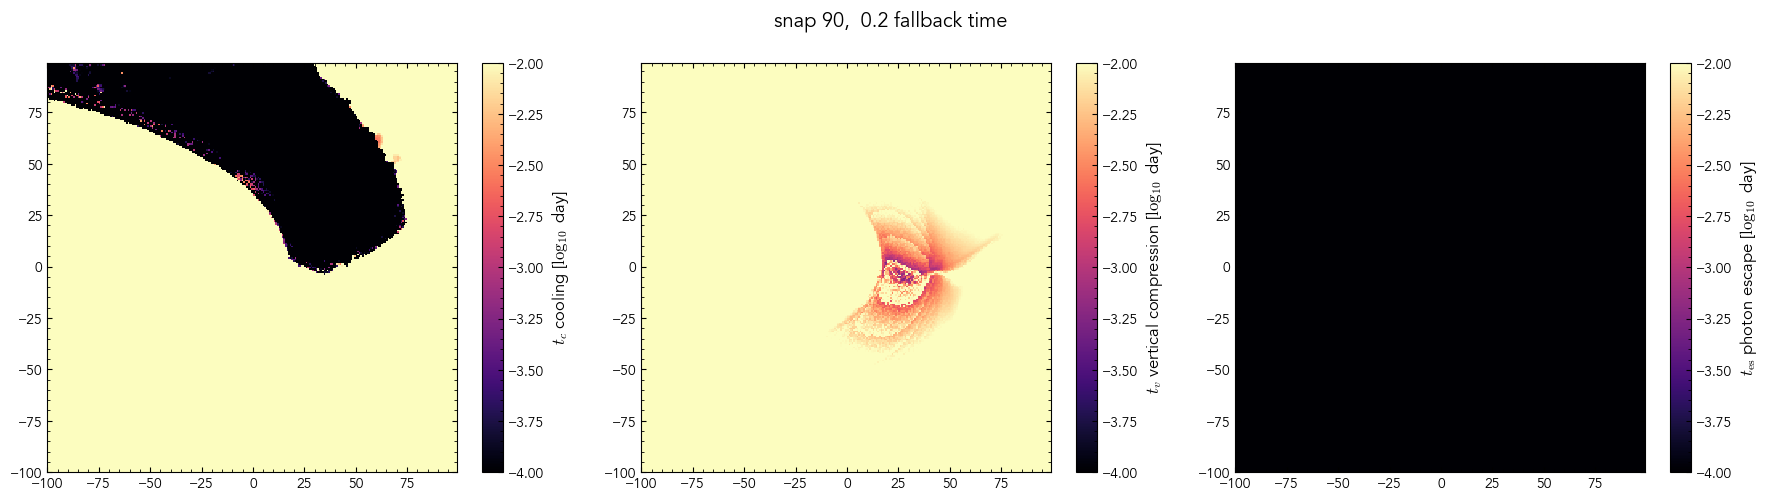

100 2.375185716526571 day


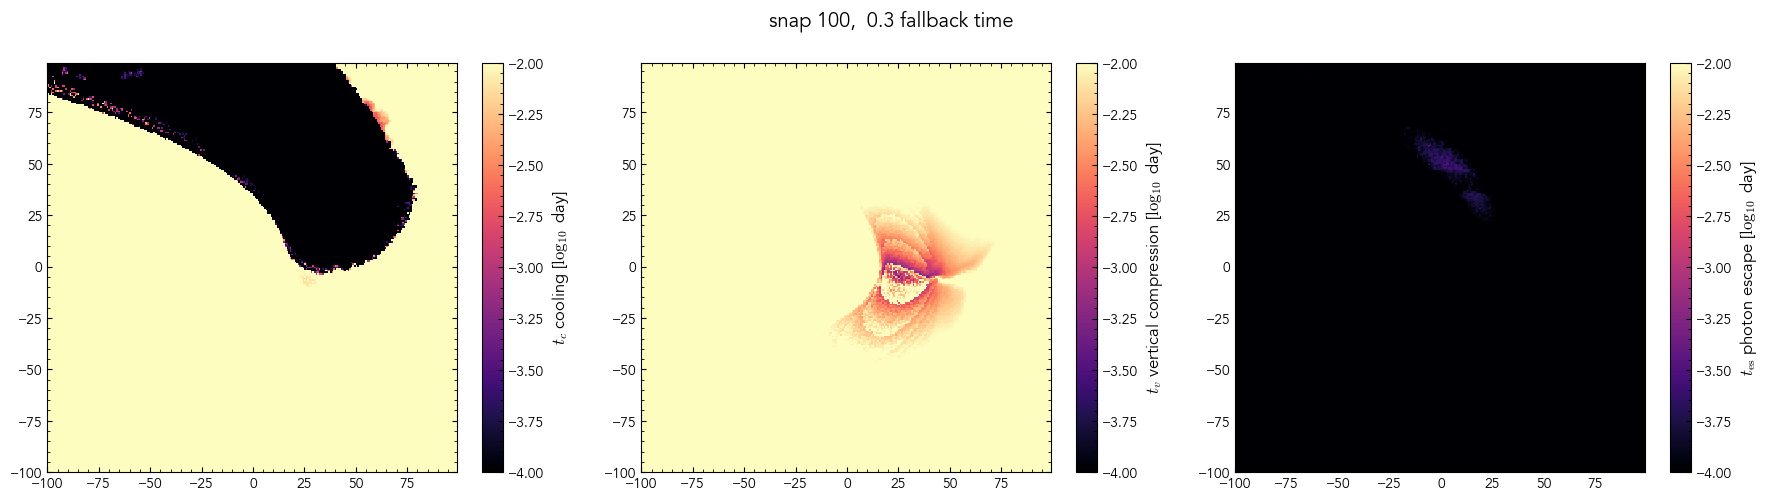

110 2.84549932970444 day


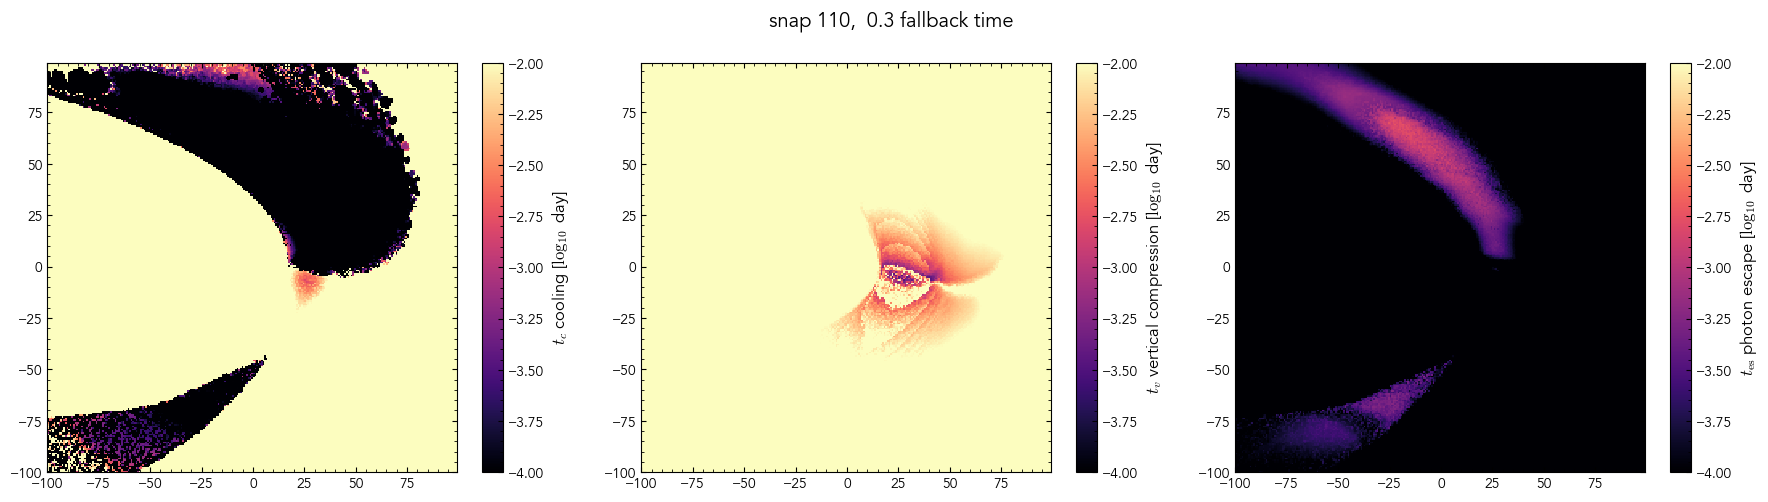

120 3.265246415632003 day


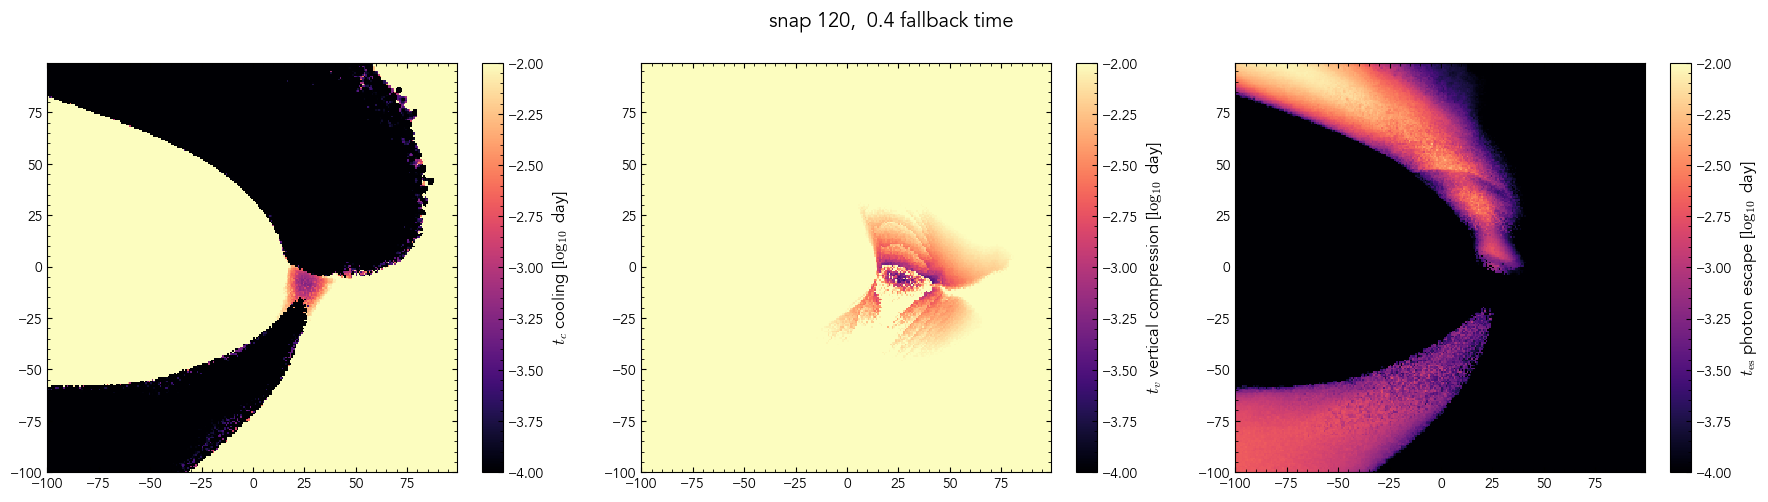

130 3.5936815510944324 day


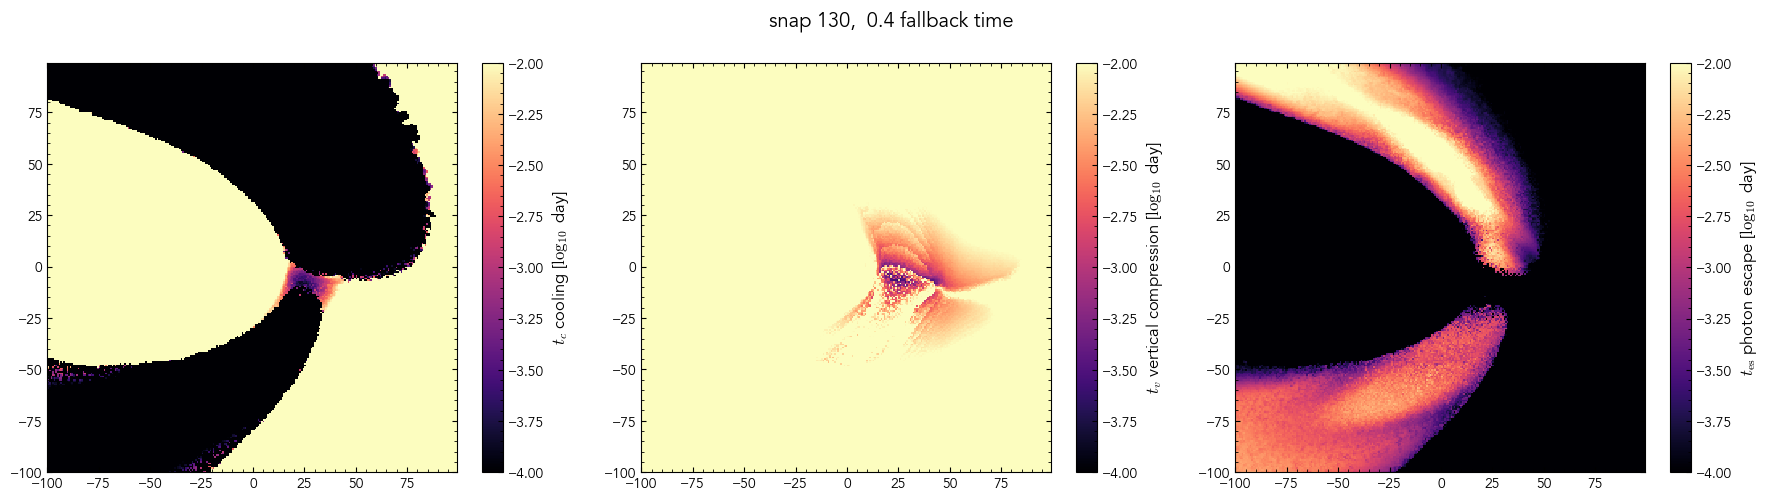

140 4.1105385899273585 day


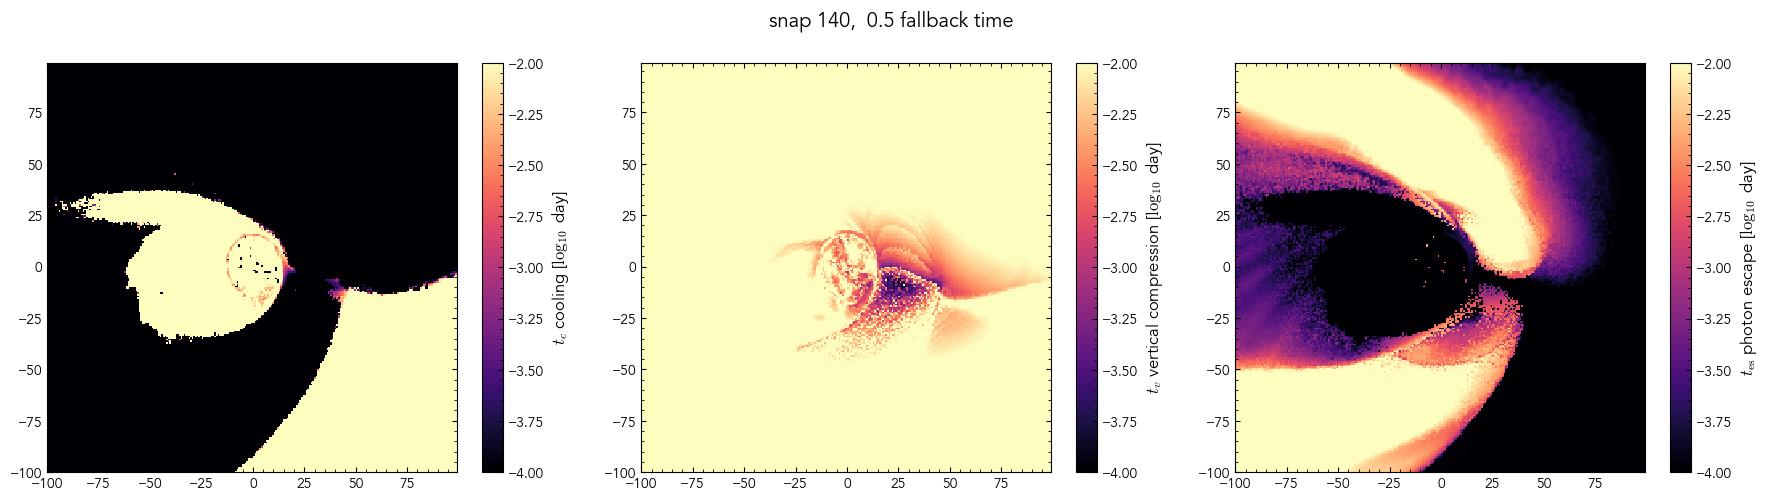

In [2]:
DATADIR = "/data1/projects/pi-rossiem/TDE_data/YujieSnellius/R0.47M0.5BH100000beta1S60n1.5ComptonHiResNewAMR"
Rstar, Mstar, Mbh = 0.47 * richio.units.lscale, 0.5 * richio.units.mscale, 1e5 * richio.units.mscale
r_p = float((Rstar * (Mbh / Mstar) ** (1 / 3)).in_units("code_length"))

XY = 100
NXY, NZ = 256, 512

for snapnum in range(70, 150, 10):
    SNAPDIR = os.path.join(DATADIR, f"snap_full_{snapnum}.h5")
    snap = richio.load(SNAPDIR)
    print(snapnum, snap.time.in_units("day"))

    alpha_ross_flat = richio.opacity.rosseland_alpha(snap.T, snap.rho)
    alpha_planck_flat = richio.opacity.planck_alpha(snap.T, snap.rho)

    box = [-XY, -XY, -10 * r_p, XY, XY, 10 * r_p]
    i, xspace, yspace, zspace = snap.to_3dgrid(res=(NXY, NXY, NZ), box_size=box)

    s = np.s_[:-1, :-1, :-1]
    rho = snap.rho[i][s]
    T = snap.T[i][s]
    vz = snap.vz[i][s]
    sie = snap.sie[i][s]
    alpha_ross = alpha_ross_flat[i][s]
    alpha_planck = alpha_planck_flat[i][s]

    dz = zspace[1:] - zspace[:-1]
    z = np.abs(zspace[:-1])

    zbar = np.sum(rho * z * dz, axis=-1) / np.sum(rho * dz, axis=-1)

    t_cool = np.sum(rho * sie * dz, axis=-1) / np.sum(
        alpha_planck * a_rad * T**4 * u.c * dz, axis=-1
    )

    tau = np.sum(alpha_ross * dz, axis=-1)
    t_escape = zbar * tau / u.c

    kbin = np.argmin(np.abs(zspace[:-1][None, None, :] - zbar[:, :, None]), axis=-1)
    vz_zbar = np.abs(np.take_along_axis(vz, kbin[:, :, None], axis=-1)[:, :, 0])
    t_compress = zbar / vz_zbar

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, tscale, title in [
        (axes[0], t_cool, r"$t_c$ cooling"),
        (axes[1], t_compress, r"$t_v$ vertical compression"),
        (axes[2], t_escape, r"$t_\mathrm{es}$ photon escape"),
    ]:
        richio.plots.scalar_map(
            tscale.in_units("day"),
            xspace,
            yspace,
            ax=ax,
            cmap="magma",
            vmin=-4,
            vmax=-2,
            colorbar_label=title + r" [$\log_{10}$ day]",
        )
    fig.suptitle(f"snap {snapnum},  {float(snap.time/(8.15*u.day)):.1f} fallback time")
    plt.tight_layout()
    plt.show()

## 10^4

21 [0.12378415] day


/tmp/ipykernel_1891629/1839947922.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fig.suptitle(f"snap {snapnum},  t = {float(snap.time.in_units('day')):.1f} day")


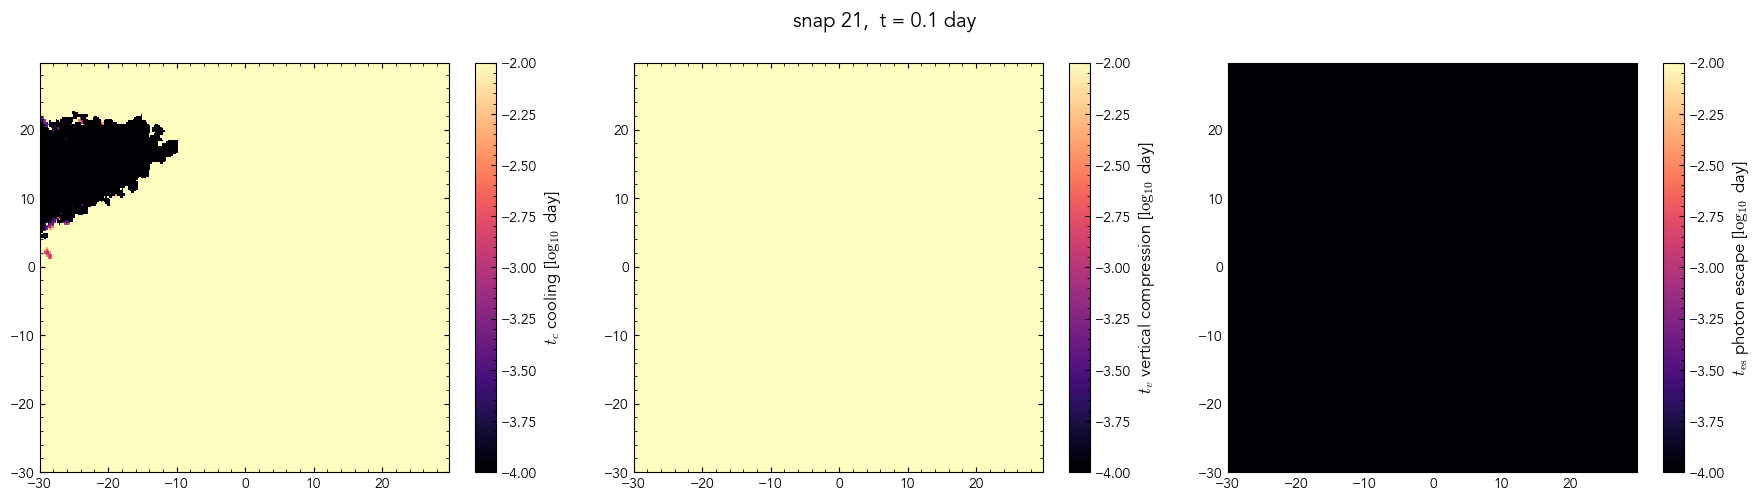

31 [0.32557589] day


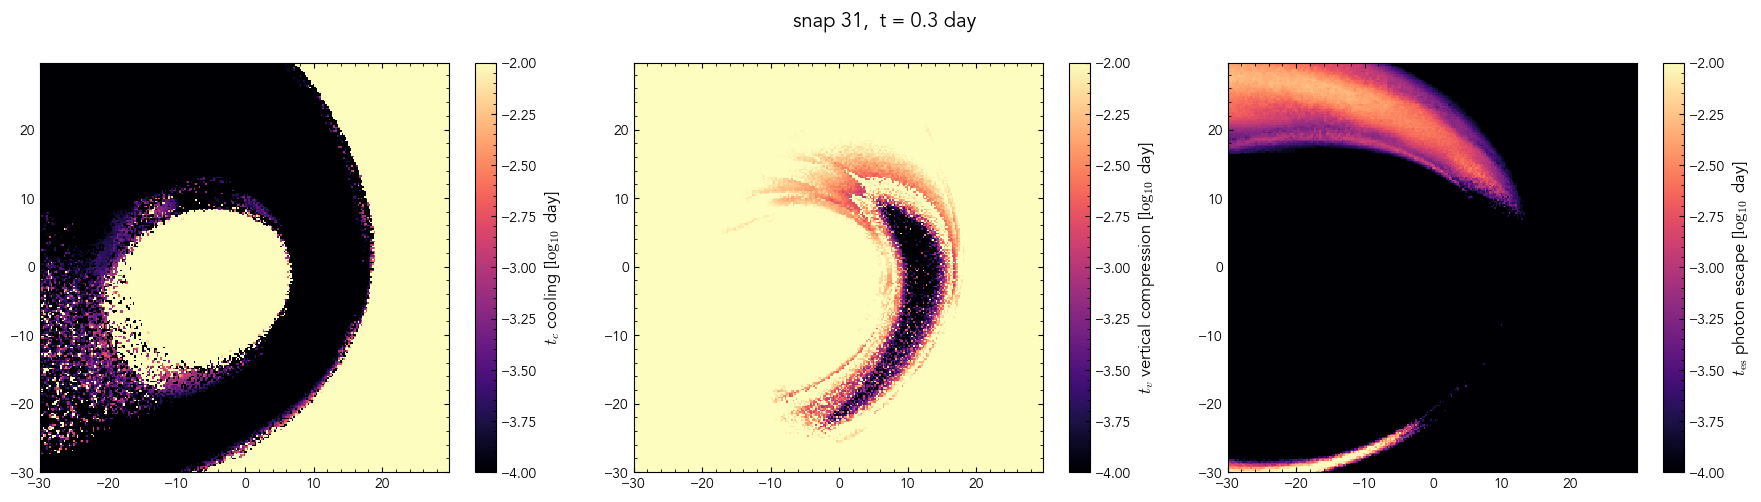

41 [0.66058558] day


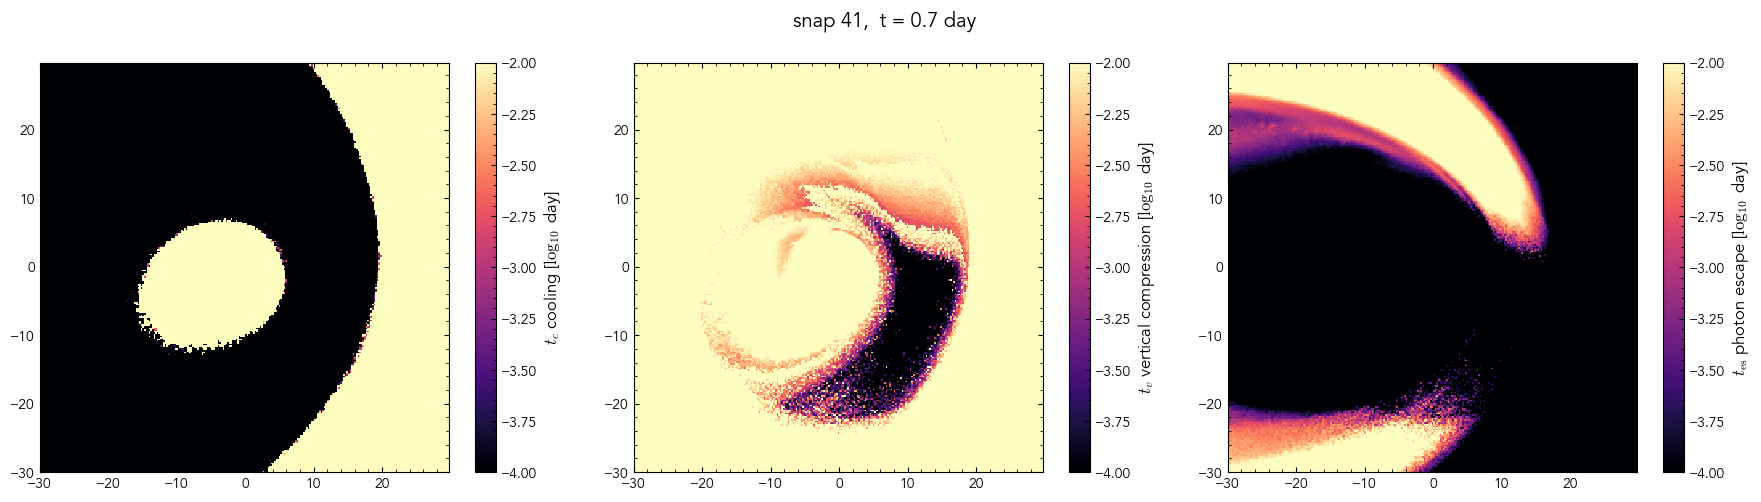

51 [1.16201337] day


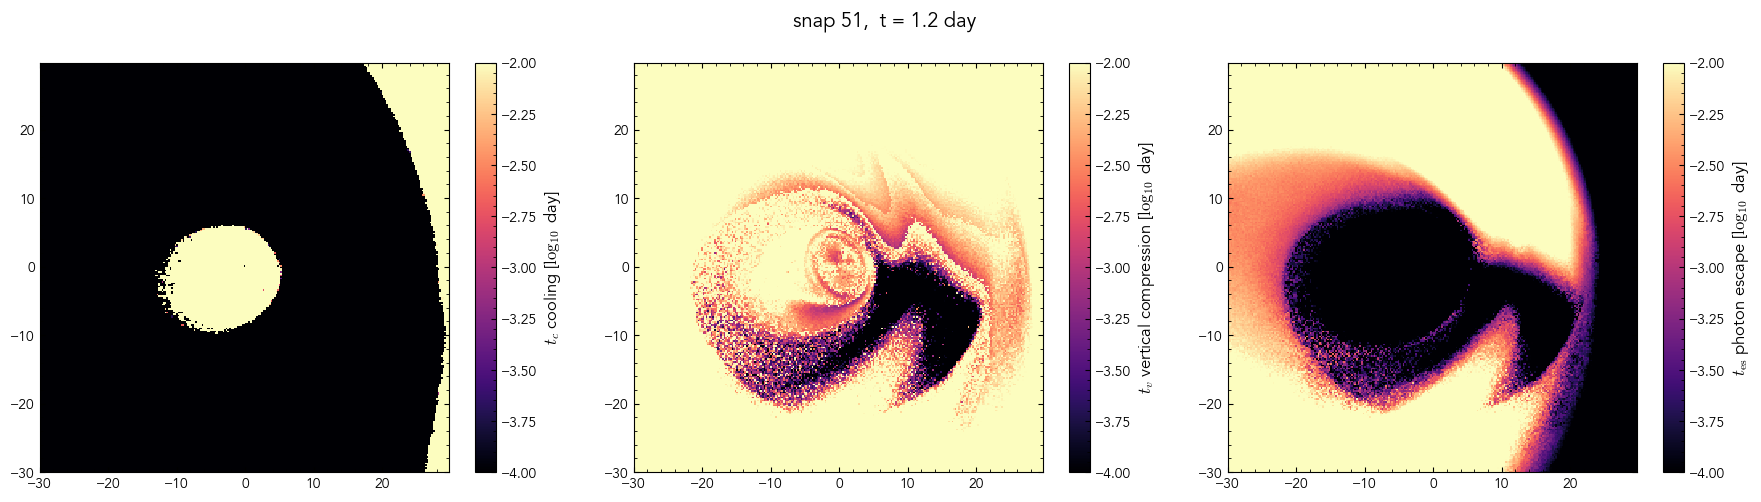

61 [1.80110022] day


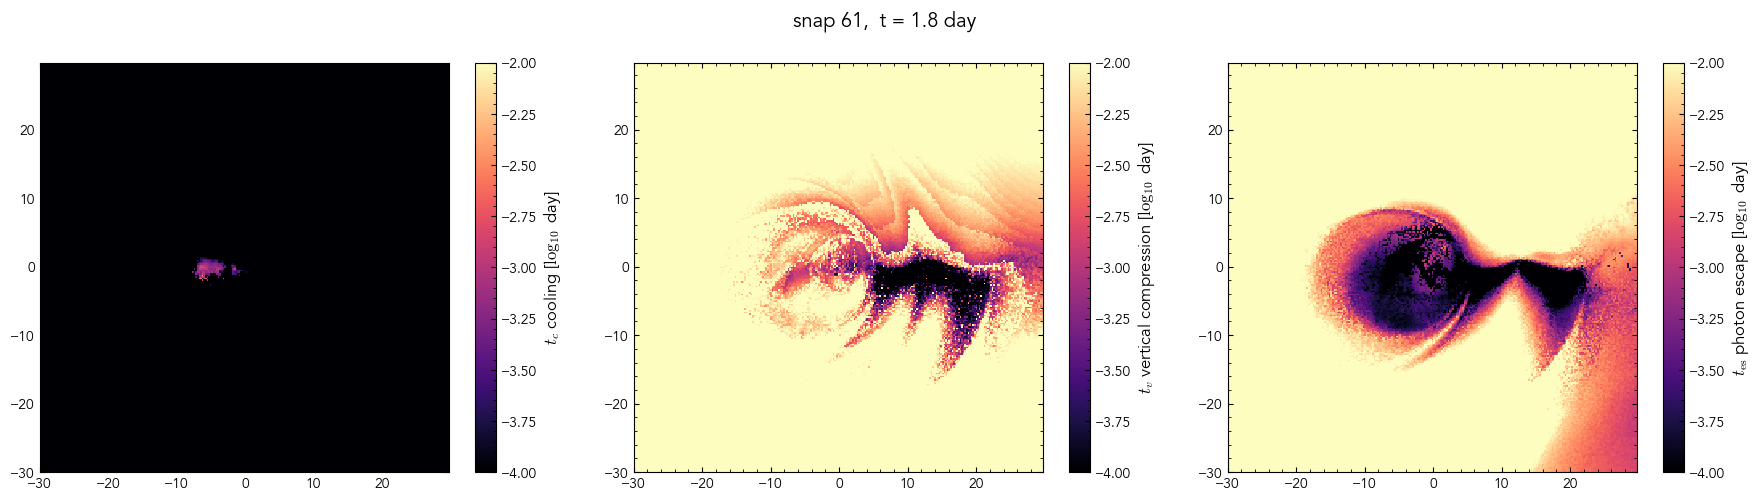

71 [2.39972335] day


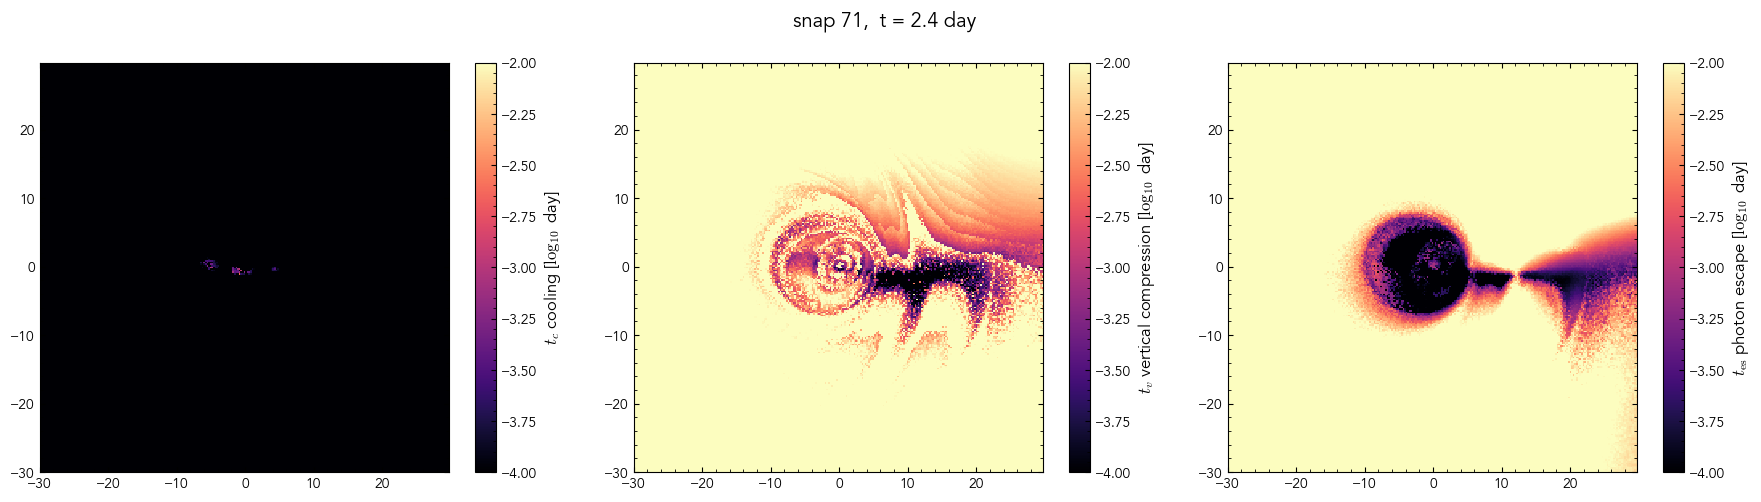

81 [2.82249649] day


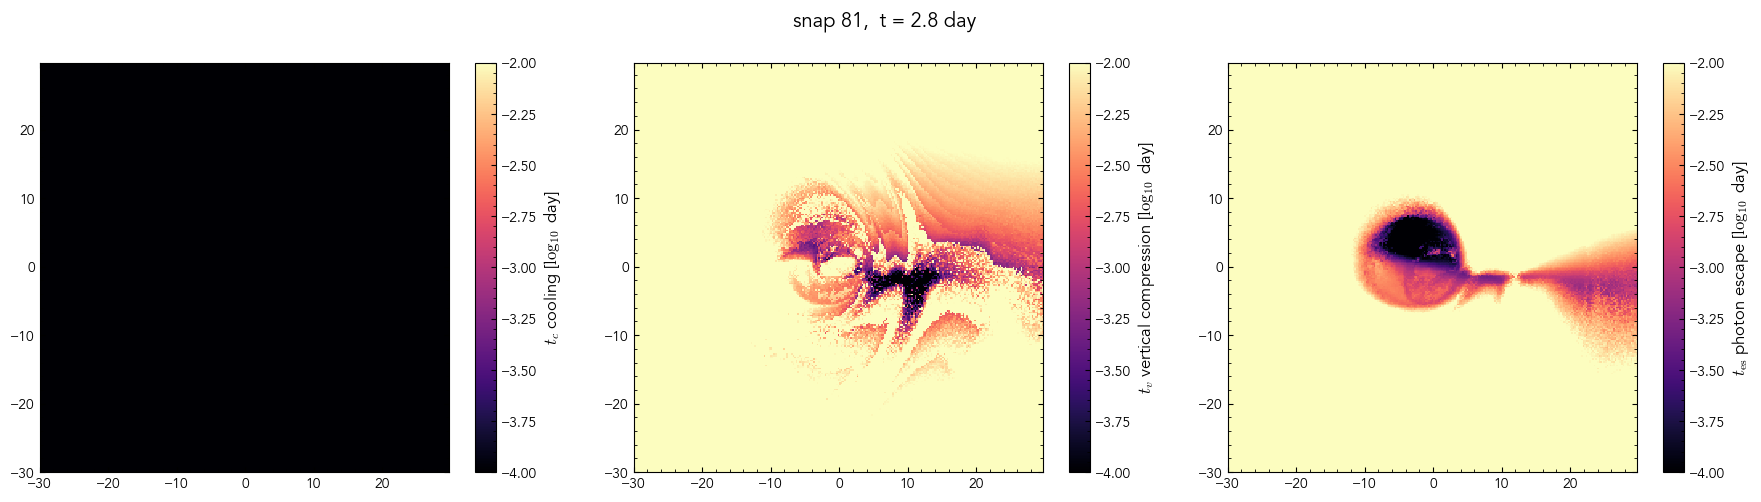

91 [3.24528112] day


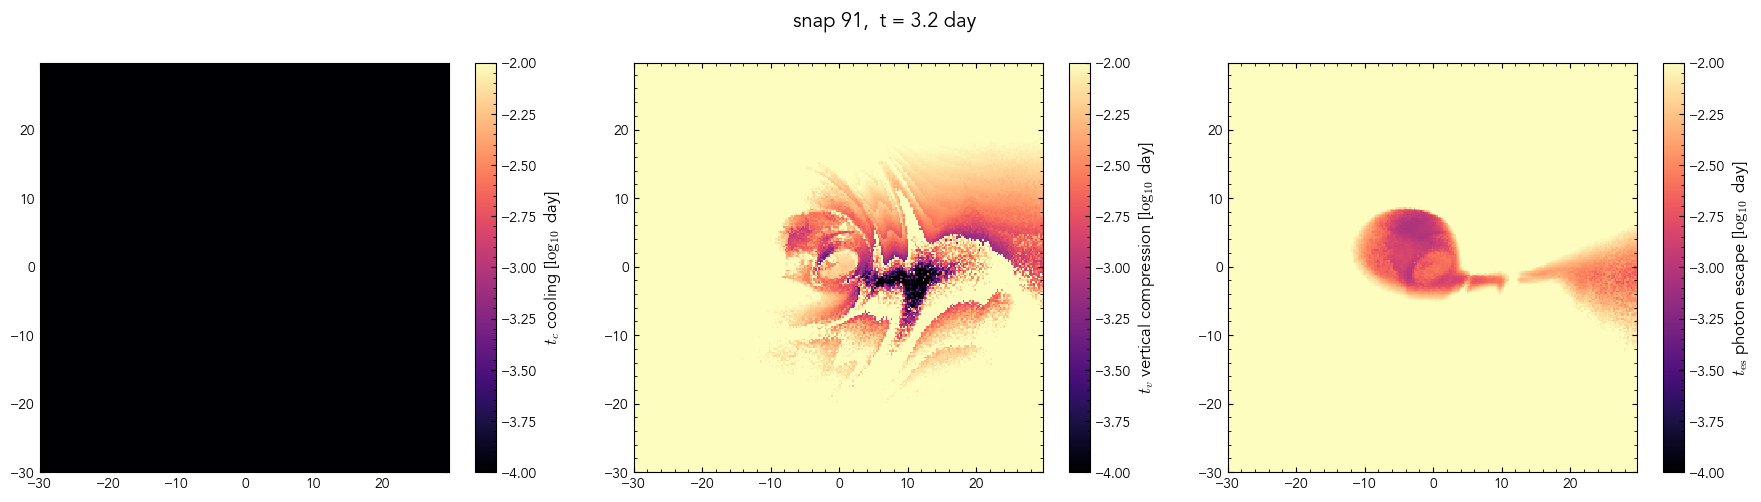

101 [3.66804655] day


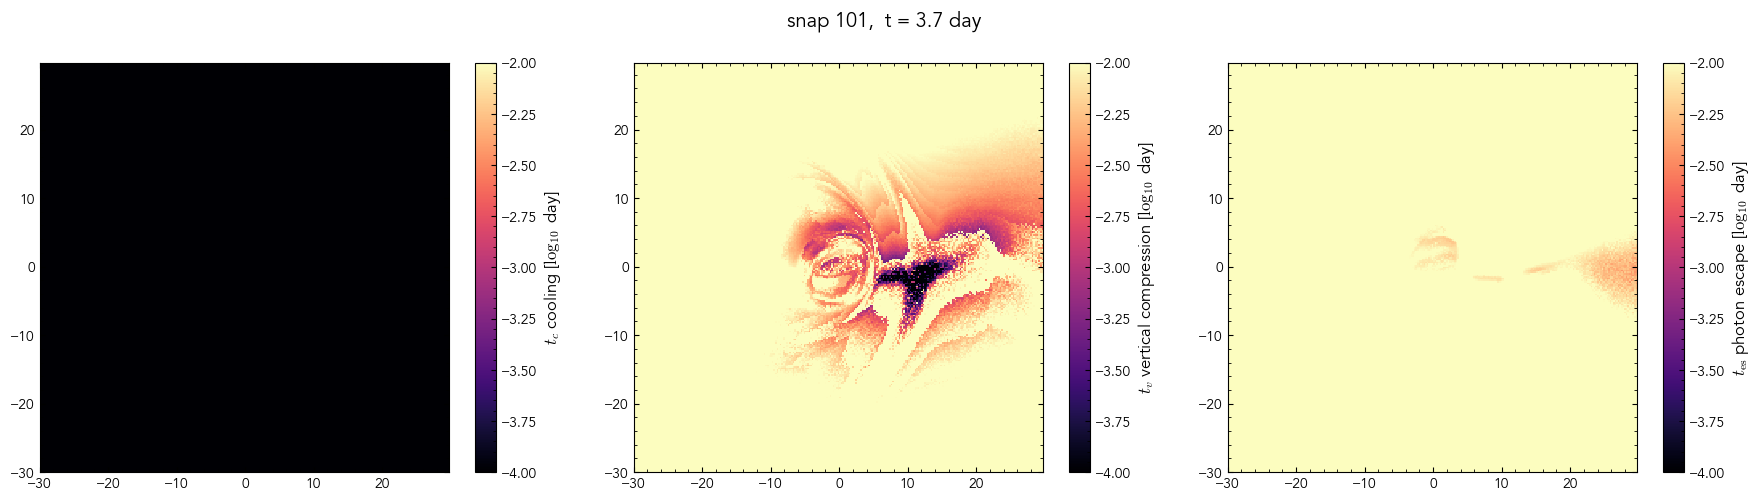

111 [4.0908111] day


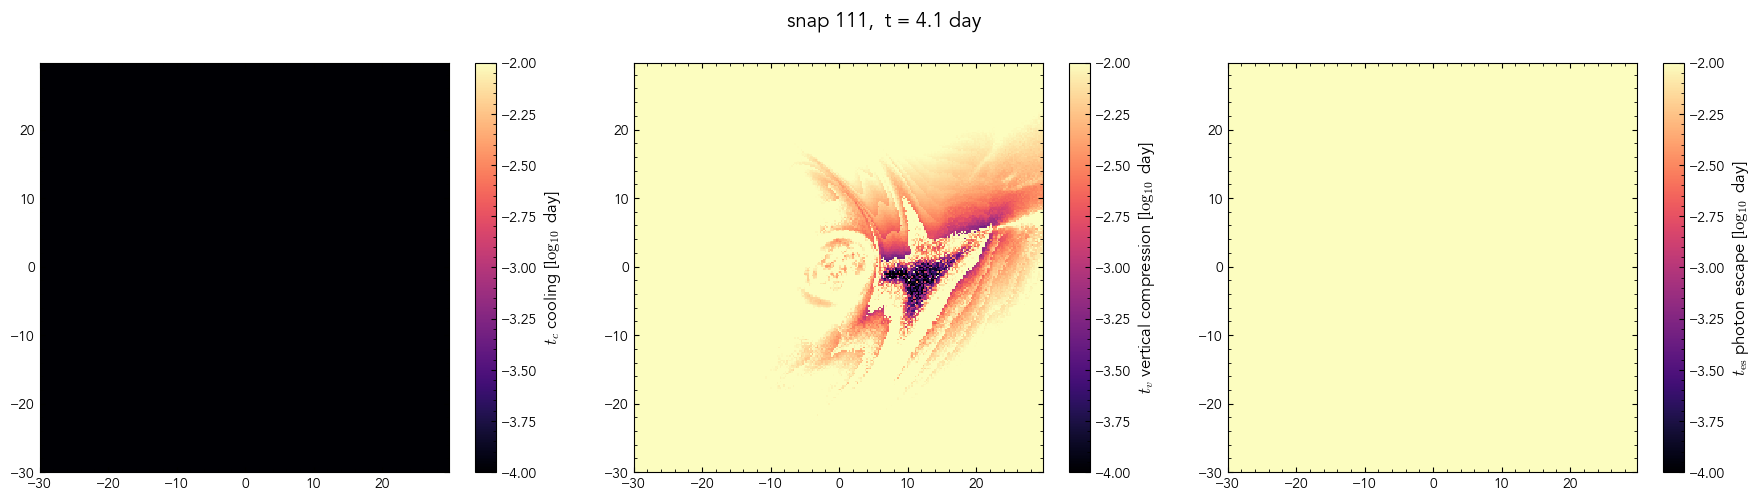

121 [4.51357501] day


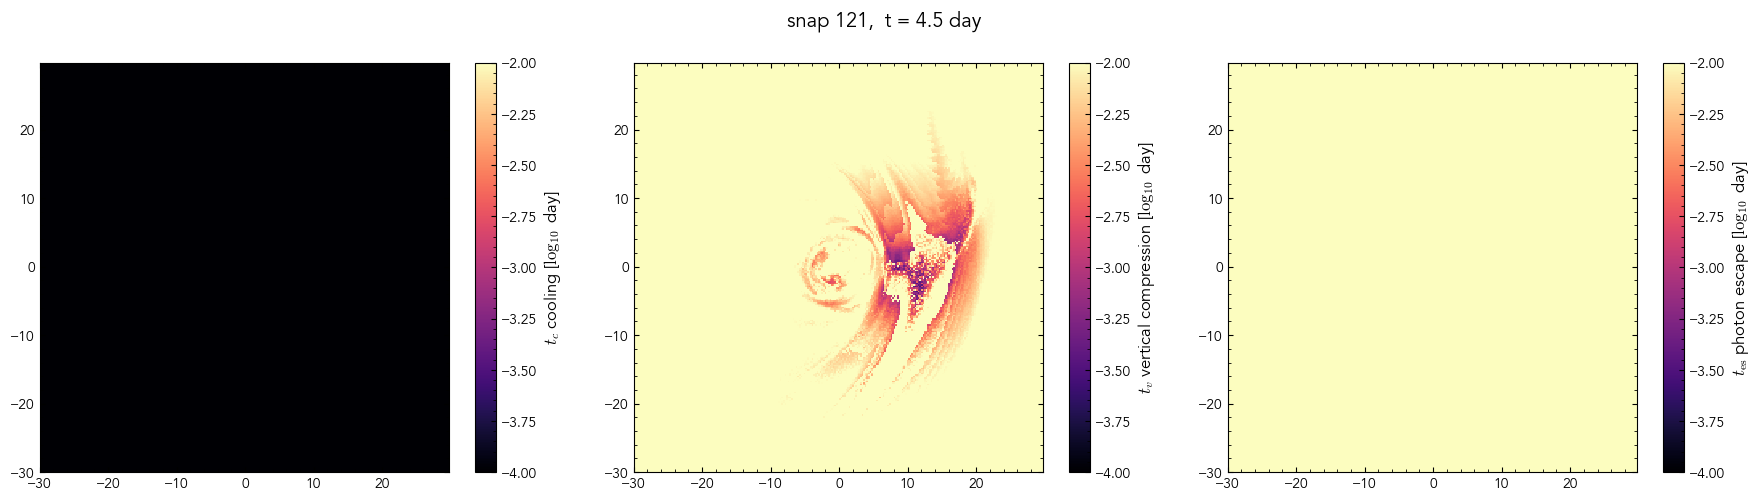

131 [4.93072563] day


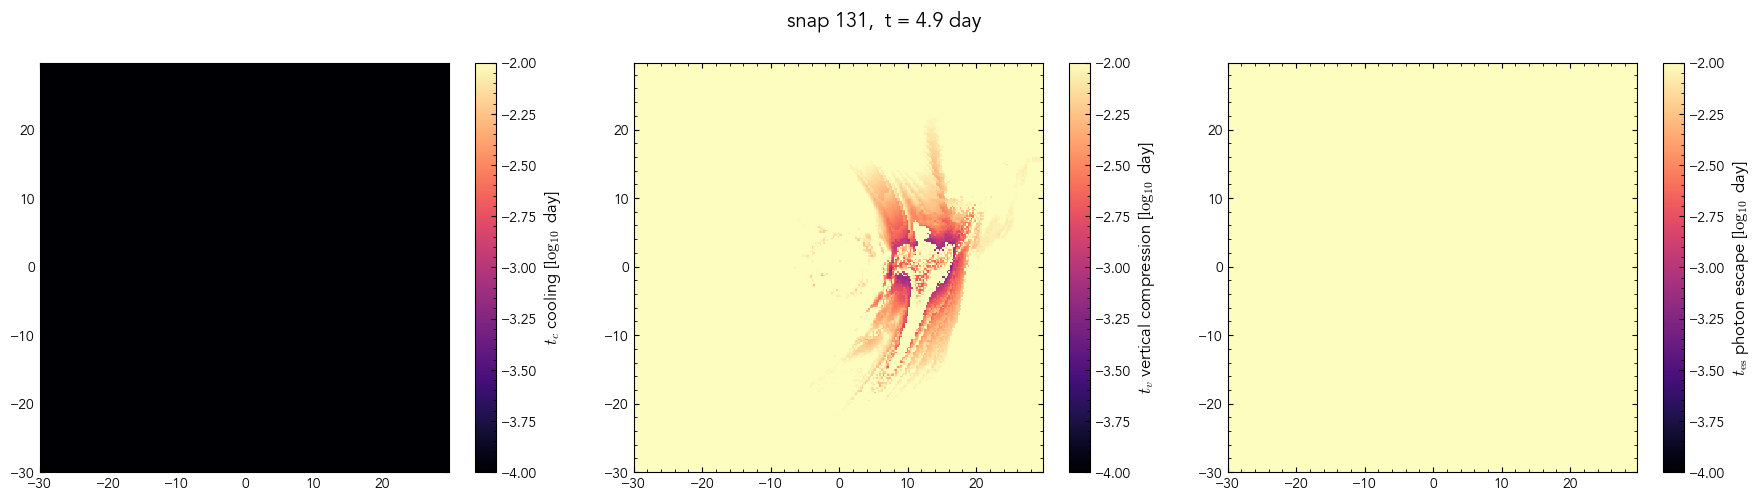

141 [5.35348215] day


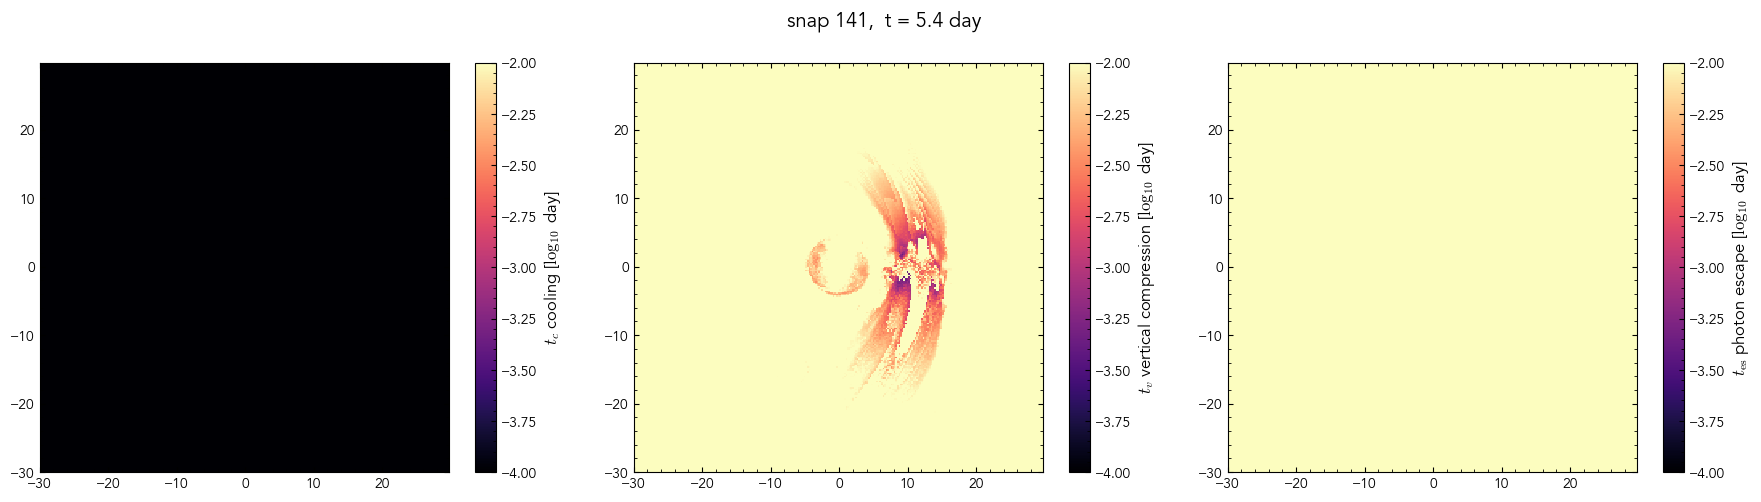

In [ ]:
DATADIR = "/data1/projects/pi-rossiem/TDE_data/NewSnellius/R0.47M0.5BH10000beta1S60ComptonHiRes"
Rstar, Mstar, Mbh = 0.47 * richio.units.lscale, 0.5 * richio.units.mscale, 1e4 * richio.units.mscale
r_p = float((Rstar * (Mbh / Mstar) ** (1 / 3)).in_units("code_length"))

XY = 30
NXY, NZ = 256, 512

for snapnum in range(21, 151, 10):
    SNAPDIR = os.path.join(DATADIR, f"snap_full_{snapnum}.h5")
    snap = richio.load(SNAPDIR)
    print(snapnum, snap.time.in_units("day"))

    alpha_ross_flat = richio.opacity.rosseland_alpha(snap.T, snap.rho)
    alpha_planck_flat = richio.opacity.planck_alpha(snap.T, snap.rho)

    box = [-XY, -XY, -10 * r_p, XY, XY, 10 * r_p]
    i, xspace, yspace, zspace = snap.to_3dgrid(res=(NXY, NXY, NZ), box_size=box)

    s = np.s_[:-1, :-1, :-1]
    rho = snap.rho[i][s]
    T = snap.T[i][s]
    vz = snap.vz[i][s]
    sie = snap.sie[i][s]
    alpha_ross = alpha_ross_flat[i][s]
    alpha_planck = alpha_planck_flat[i][s]

    dz = zspace[1:] - zspace[:-1]
    z = np.abs(zspace[:-1])

    zbar = np.sum(rho * z * dz, axis=-1) / np.sum(rho * dz, axis=-1)

    t_cool = np.sum(rho * sie * dz, axis=-1) / np.sum(
        alpha_planck * a_rad * T**4 * u.c * dz, axis=-1
    )

    tau = np.sum(alpha_ross * dz, axis=-1)
    t_escape = zbar * tau / u.c

    kbin = np.argmin(np.abs(zspace[:-1][None, None, :] - zbar[:, :, None]), axis=-1)
    vz_zbar = np.abs(np.take_along_axis(vz, kbin[:, :, None], axis=-1)[:, :, 0])
    t_compress = zbar / vz_zbar

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, tscale, title in [
        (axes[0], t_cool, r"$t_c$ cooling"),
        (axes[1], t_compress, r"$t_v$ vertical compression"),
        (axes[2], t_escape, r"$t_\mathrm{es}$ photon escape"),
    ]:
        richio.plots.scalar_map(
            tscale.in_units("day"),
            xspace,
            yspace,
            ax=ax,
            vmin=-4,
            vmax=-2,
            cmap="magma",
            colorbar_label=title + r" [$\log_{10}$ day]",
        )
    fig.suptitle(
        f"snap {snapnum},  {float(snap.time / (2.5 * u.day)):.1f} fallback time"
    )
    plt.tight_layout()
    plt.show()

## 10^6

720 [24.04665922] day


/tmp/ipykernel_1891629/1395871197.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fig.suptitle(f"snap {snapnum},  t = {float(snap.time.in_units('day')):.1f} day")


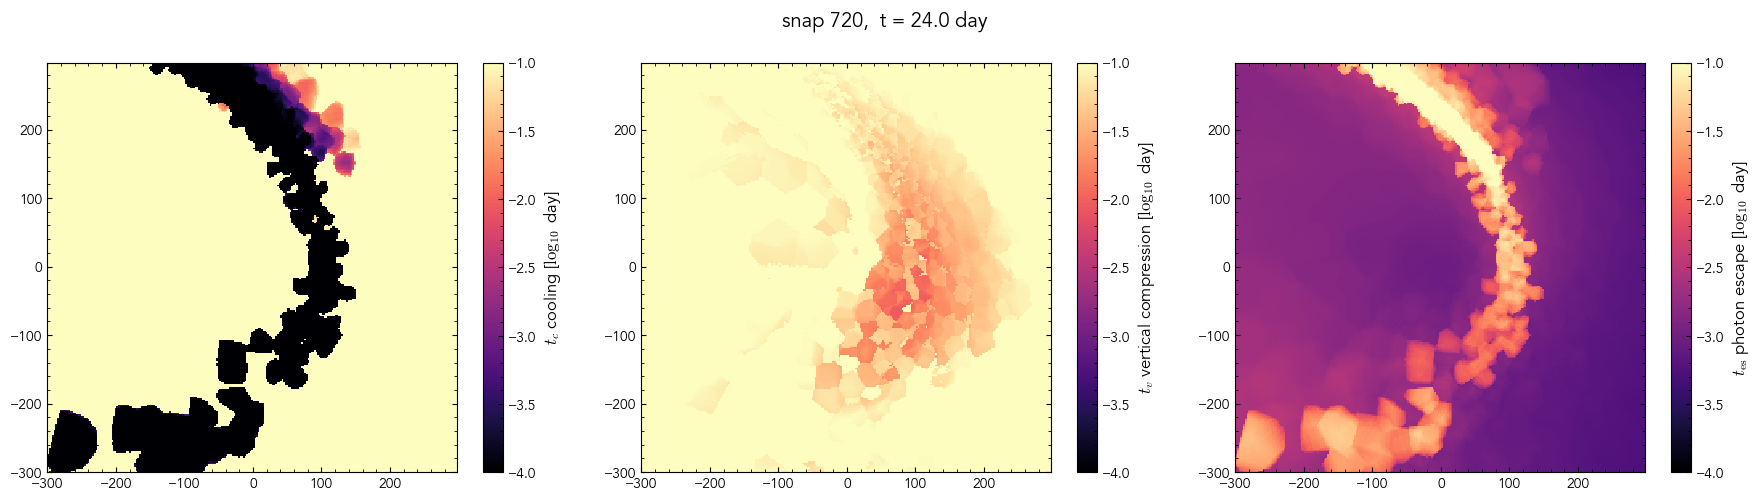

750 [27.5057264] day


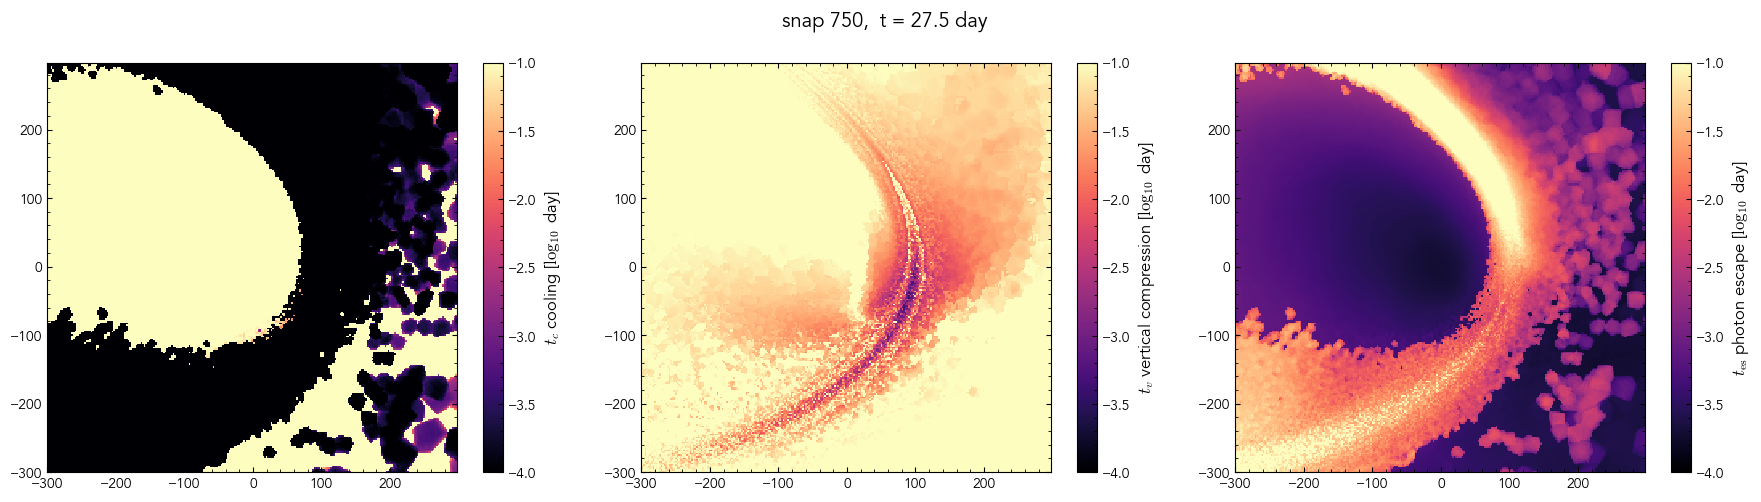

780 [31.28071019] day


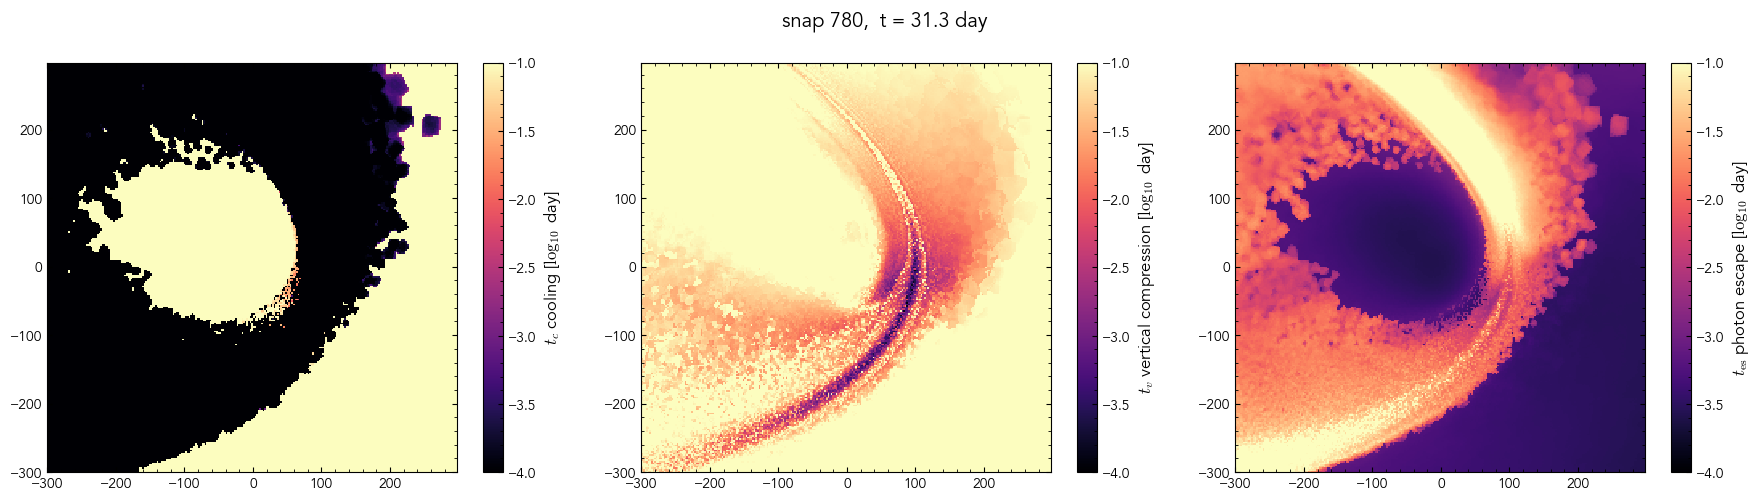

810 [35.38587044] day


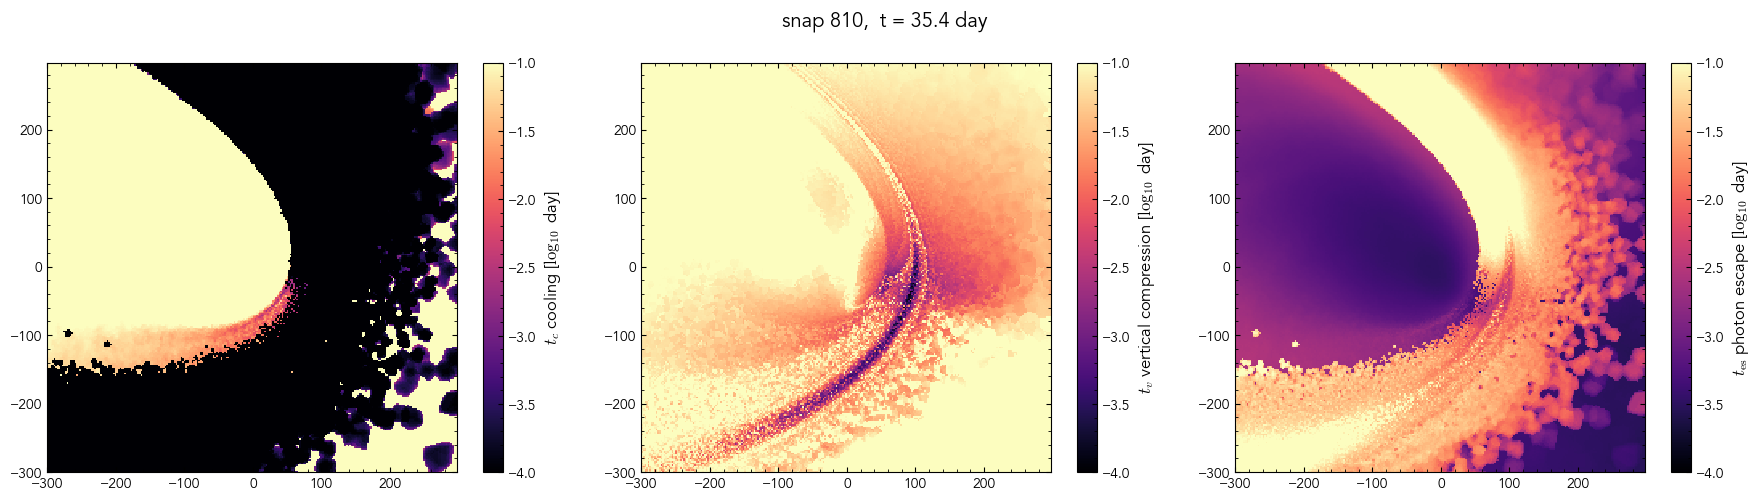

In [4]:
DATADIR = "/data1/projects/pi-rossiem/TDE_data/SS24/TEMPTDE4"
Rstar, Mstar, Mbh = 1 * richio.units.lscale, 1 * richio.units.mscale, 1e6 * richio.units.mscale
r_p = float((Rstar * (Mbh / Mstar) ** (1 / 3)).in_units("code_length"))

XY = 300
NXY, NZ = 256, 512

for snapnum in range(720, 820, 30):
    SNAPDIR = os.path.join(DATADIR, f"snap_{snapnum}.h5")
    snap = richio.load(SNAPDIR)
    print(snapnum, snap.time.in_units("day"))

    alpha_ross_flat = richio.opacity.rosseland_alpha(snap.T, snap.rho)
    alpha_planck_flat = richio.opacity.planck_alpha(snap.T, snap.rho)

    box = [-XY, -XY, -10 * r_p, XY, XY, 10 * r_p]
    i, xspace, yspace, zspace = snap.to_3dgrid(res=(NXY, NXY, NZ), box_size=box)

    s = np.s_[:-1, :-1, :-1]
    rho = snap.rho[i][s]
    T = snap.T[i][s]
    vz = snap.vz[i][s]
    sie = snap.sie[i][s]
    alpha_ross = alpha_ross_flat[i][s]
    alpha_planck = alpha_planck_flat[i][s]

    dz = zspace[1:] - zspace[:-1]
    z = np.abs(zspace[:-1])

    zbar = np.sum(rho * z * dz, axis=-1) / np.sum(rho * dz, axis=-1)

    t_cool = np.sum(rho * sie * dz, axis=-1) / np.sum(
        alpha_planck * a_rad * T**4 * u.c * dz, axis=-1
    )

    tau = np.sum(alpha_ross * dz, axis=-1)
    t_escape = zbar * tau / u.c

    kbin = np.argmin(np.abs(zspace[:-1][None, None, :] - zbar[:, :, None]), axis=-1)
    vz_zbar = np.abs(np.take_along_axis(vz, kbin[:, :, None], axis=-1)[:, :, 0])
    t_compress = zbar / vz_zbar

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, tscale, title in [
        (axes[0], t_cool, r"$t_c$ cooling"),
        (axes[1], t_compress, r"$t_v$ vertical compression"),
        (axes[2], t_escape, r"$t_\mathrm{es}$ photon escape"),
    ]:
        richio.plots.scalar_map(
            tscale.in_units("day"),
            xspace,
            yspace,
            ax=ax,
            cmap="magma",
            vmin=-4,
            vmax=-1,
            colorbar_label=title + r" [$\log_{10}$ day]",
        )
    fig.suptitle(f"snap {snapnum},  t = {float(snap.time.in_units('day')):.1f} day")
    plt.tight_layout()
    plt.show()

820 [36.83005433] day


/tmp/ipykernel_1891629/2223951920.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fig.suptitle(f"snap {snapnum},  t = {float(snap.time.in_units('day')):.1f} day")


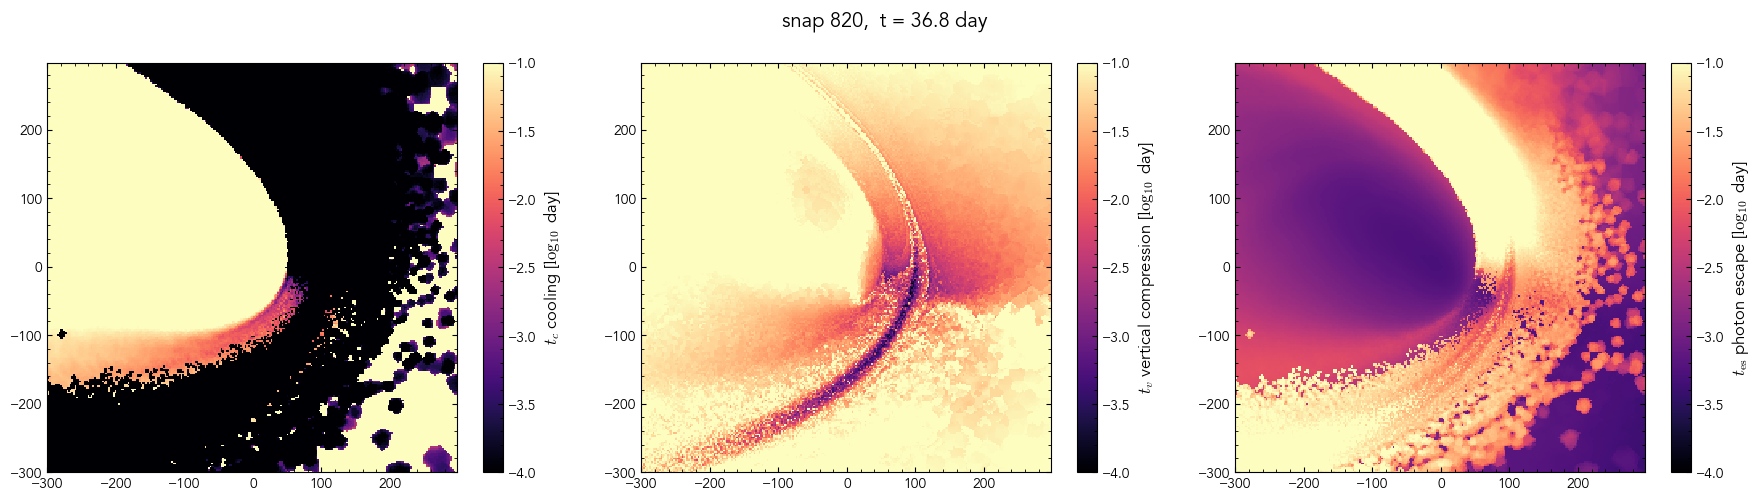

870 [44.24683567] day


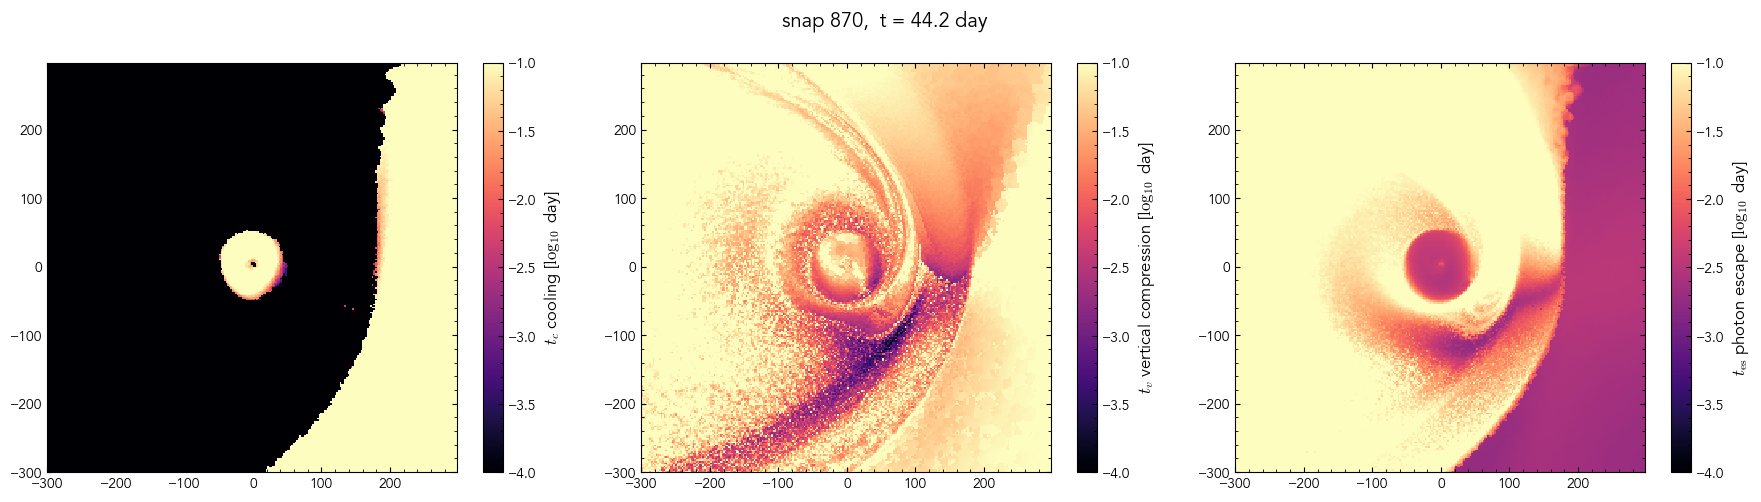

920 [51.66896875] day


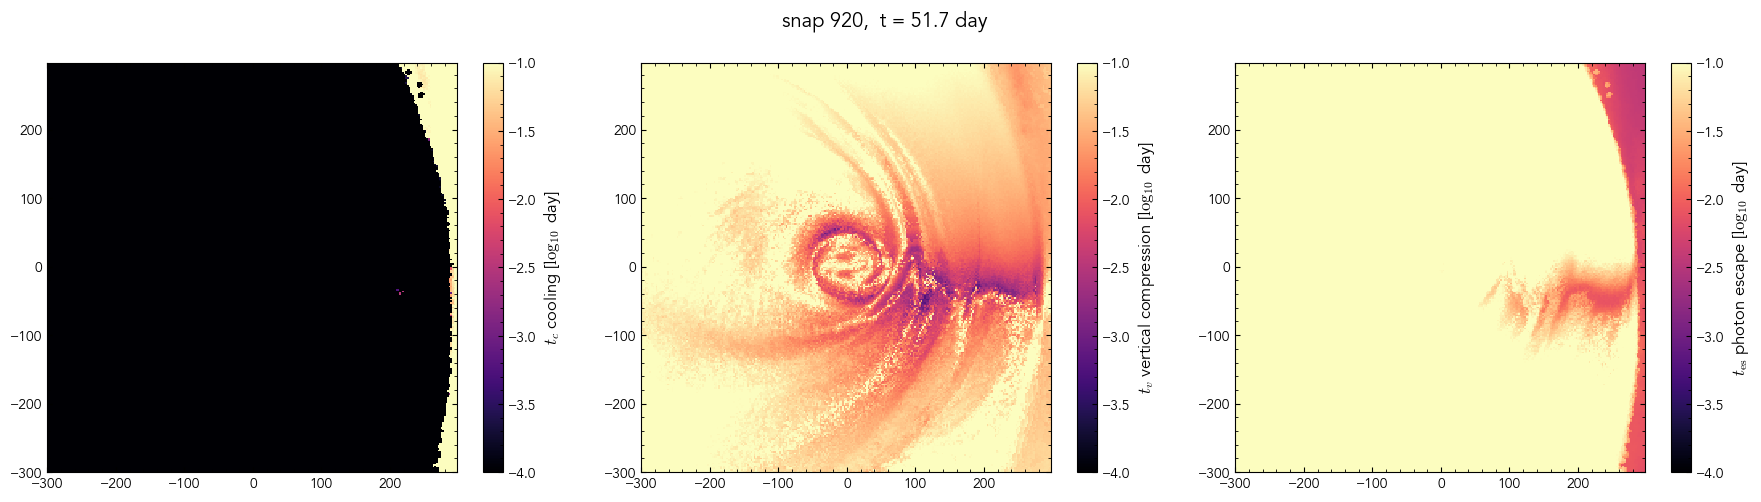

970 [59.09121738] day


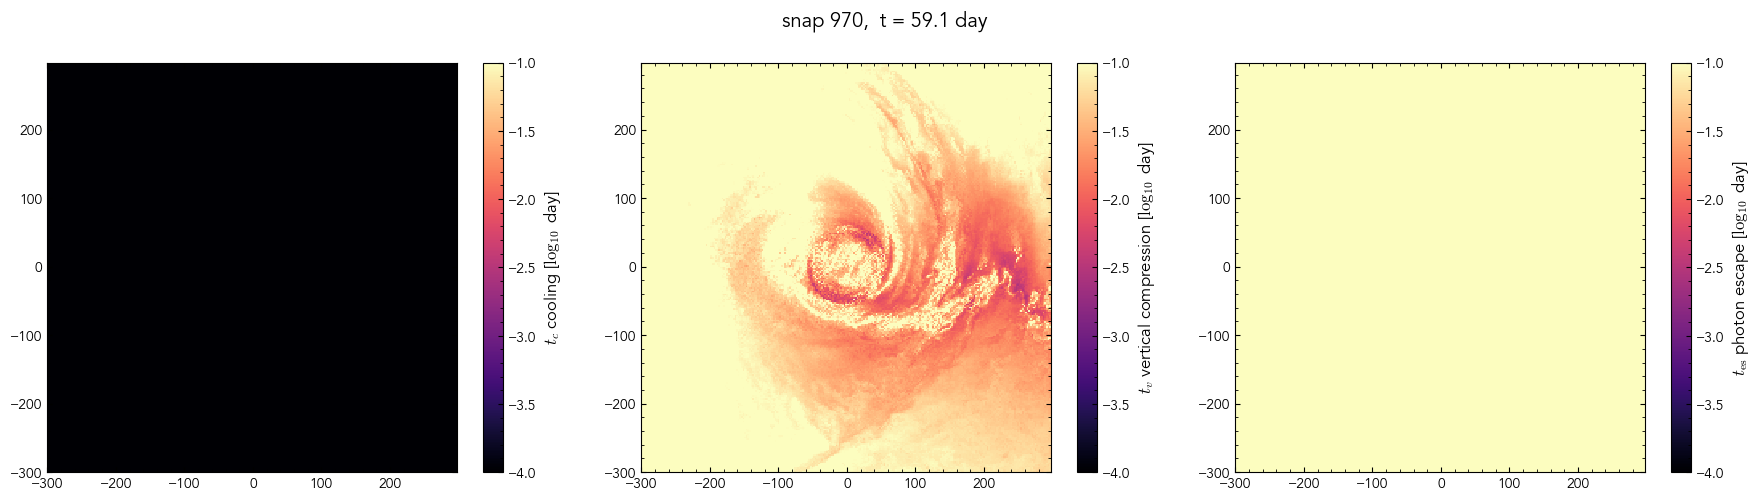

In [5]:
DATADIR = "/data1/projects/pi-rossiem/TDE_data/SS24/TEMPTDE4_new"
Rstar, Mstar, Mbh = (
    1 * richio.units.lscale,
    1 * richio.units.mscale,
    1e6 * richio.units.mscale,
)
r_p = float((Rstar * (Mbh / Mstar) ** (1 / 3)).in_units("code_length"))

XY = 300
NXY, NZ = 256, 512

for snapnum in range(820, 1000, 50):
    SNAPDIR = os.path.join(DATADIR, f"snap_{snapnum}.h5")
    snap = richio.load(SNAPDIR)
    print(snapnum, snap.time.in_units("day"))

    alpha_ross_flat = richio.opacity.rosseland_alpha(snap.T, snap.rho)
    alpha_planck_flat = richio.opacity.planck_alpha(snap.T, snap.rho)

    box = [-XY, -XY, -10 * r_p, XY, XY, 10 * r_p]
    i, xspace, yspace, zspace = snap.to_3dgrid(res=(NXY, NXY, NZ), box_size=box)

    s = np.s_[:-1, :-1, :-1]
    rho = snap.rho[i][s]
    T = snap.T[i][s]
    vz = snap.vz[i][s]
    sie = snap.sie[i][s]
    alpha_ross = alpha_ross_flat[i][s]
    alpha_planck = alpha_planck_flat[i][s]

    dz = zspace[1:] - zspace[:-1]
    z = np.abs(zspace[:-1])

    zbar = np.sum(rho * z * dz, axis=-1) / np.sum(rho * dz, axis=-1)

    t_cool = np.sum(rho * sie * dz, axis=-1) / np.sum(
        alpha_planck * a_rad * T**4 * u.c * dz, axis=-1
    )

    tau = np.sum(alpha_ross * dz, axis=-1)
    t_escape = zbar * tau / u.c

    kbin = np.argmin(np.abs(zspace[:-1][None, None, :] - zbar[:, :, None]), axis=-1)
    vz_zbar = np.abs(np.take_along_axis(vz, kbin[:, :, None], axis=-1)[:, :, 0])
    t_compress = zbar / vz_zbar

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, tscale, title in [
        (axes[0], t_cool, r"$t_c$ cooling"),
        (axes[1], t_compress, r"$t_v$ vertical compression"),
        (axes[2], t_escape, r"$t_\mathrm{es}$ photon escape"),
    ]:
        richio.plots.scalar_map(
            tscale.in_units("day"),
            xspace,
            yspace,
            ax=ax,
            cmap="magma",
            vmin=-4,
            vmax=-1,
            colorbar_label=title + r" [$\log_{10}$ day]",
        )
    fig.suptitle(f"snap {snapnum},  t = {float(snap.time.in_units('day')):.1f} day")
    plt.tight_layout()
    plt.show()
